# AI 모델 검증 및 평가 예제 - TensorFlow/Keras 버전

이 노트북은 AI 모델 검증과 평가의 기본 흐름을 TensorFlow/Keras로 실습하는 예제입니다.

실습 내용은 다음과 같습니다.

1. 데이터 준비
2. 학습 데이터, 검증 데이터, 테스트 데이터 분리
3. Keras Sequential 모델 정의
4. 학습 중 검증 손실과 검증 정확도 확인
5. 테스트 데이터 최종 평가
6. Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC-AUC 계산
7. 학습 곡선 시각화

분류 문제 예제로 `Breast Cancer` 데이터셋을 사용합니다.

In [1]:
# ============================================================
# 1. 필요한 라이브러리 불러오기
# ============================================================

# numpy는 배열 계산을 위한 기본 라이브러리입니다.
import numpy as np

# pandas는 표 형태의 데이터를 다룰 때 사용합니다.
import pandas as pd

# matplotlib은 그래프를 그릴 때 사용합니다.
import matplotlib.pyplot as plt

# TensorFlow는 딥러닝 모델을 만들고 학습할 때 사용하는 라이브러리입니다.
import tensorflow as tf

# keras는 TensorFlow 안에서 신경망 모델을 쉽게 만들 수 있도록 도와주는 API입니다.
from tensorflow import keras

# Dense는 완전연결층을 만들 때 사용합니다.
from tensorflow.keras.layers import Dense, Dropout

# Sequential은 계층을 순서대로 쌓는 모델 방식입니다.
from tensorflow.keras.models import Sequential

# EarlyStopping은 검증 성능이 더 이상 좋아지지 않으면 학습을 조기 종료합니다.
from tensorflow.keras.callbacks import EarlyStopping

# sklearn의 유방암 데이터셋을 불러옵니다.
from sklearn.datasets import load_breast_cancer

# train_test_split은 데이터를 학습/검증/테스트 데이터로 나눌 때 사용합니다.
from sklearn.model_selection import train_test_split

# StandardScaler는 입력 특성값을 평균 0, 표준편차 1로 표준화합니다.
from sklearn.preprocessing import StandardScaler

# 평가 지표를 계산하기 위한 함수들입니다.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# 실행할 때마다 최대한 같은 결과가 나오도록 난수를 고정합니다.
np.random.seed(42)

# TensorFlow의 난수를 고정합니다.
tf.random.set_seed(42)

# TensorFlow 버전을 출력합니다.
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================

# Breast Cancer 데이터셋을 불러옵니다.
# 이 데이터셋은 종양이 악성인지 양성인지 분류하는 이진 분류 데이터입니다.
data = load_breast_cancer()

# 입력 데이터 X를 가져옵니다.
X = data.data

# 정답 데이터 y를 가져옵니다.
y = data.target

# 데이터 확인을 위해 DataFrame으로 변환합니다.
df = pd.DataFrame(X, columns=data.feature_names)

# 정답 컬럼을 추가합니다.
df["target"] = y

# 데이터의 앞부분 5개 행을 출력합니다.
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# ============================================================
# 3. 학습 데이터, 검증 데이터, 테스트 데이터 분리
# ============================================================

# 먼저 전체 데이터를 학습+검증 데이터와 테스트 데이터로 나눕니다.
# test_size=0.15는 전체 데이터의 15%를 최종 평가용 테스트 데이터로 사용한다는 의미입니다.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 학습+검증 데이터를 다시 학습 데이터와 검증 데이터로 나눕니다.
# 전체 기준으로 약 70% 학습, 15% 검증, 15% 테스트가 되도록 구성합니다.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_val
)

# 각 데이터 크기를 출력합니다.
print("학습 데이터 크기:", X_train.shape)
print("검증 데이터 크기:", X_val.shape)
print("테스트 데이터 크기:", X_test.shape)

# 클래스 분포를 확인합니다.
print("학습 정답 분포:", np.bincount(y_train))
print("검증 정답 분포:", np.bincount(y_val))
print("테스트 정답 분포:", np.bincount(y_test))

학습 데이터 크기: (397, 30)
검증 데이터 크기: (86, 30)
테스트 데이터 크기: (86, 30)
학습 정답 분포: [148 249]
검증 정답 분포: [32 54]
테스트 정답 분포: [32 54]


In [4]:
# ============================================================
# 4. 입력 데이터 표준화
# ============================================================

# StandardScaler 객체를 생성합니다.
scaler = StandardScaler()

# 학습 데이터에 대해서만 평균과 표준편차를 계산하고 변환합니다.
# 검증/테스트 데이터 정보가 학습에 섞이지 않도록 fit은 학습 데이터에만 사용합니다.
X_train_scaled = scaler.fit_transform(X_train)

# 검증 데이터는 학습 데이터 기준으로 변환만 합니다.
X_val_scaled = scaler.transform(X_val)

# 테스트 데이터도 학습 데이터 기준으로 변환만 합니다.
X_test_scaled = scaler.transform(X_test)

In [5]:
# ============================================================
# 5. Keras 모델 정의
# ============================================================

# 입력 특성 개수를 구합니다.
input_dim = X_train_scaled.shape[1]

# Sequential 모델은 층을 순서대로 쌓는 가장 기본적인 Keras 모델 방식입니다.
model = Sequential([
    # 첫 번째 Dense 층입니다.
    # units=32는 출력 뉴런 수가 32개라는 뜻입니다.
    # activation='relu'는 ReLU 활성화 함수를 사용한다는 뜻입니다.
    # input_shape=(input_dim,)은 입력 특성 개수를 모델에 알려주는 설정입니다.
    Dense(32, activation="relu", input_shape=(input_dim,)),

    # Dropout은 학습 중 일부 뉴런을 무작위로 끄는 방식입니다.
    # 과적합을 줄이는 데 도움을 줍니다.
    Dropout(0.2),

    # 두 번째 Dense 층입니다.
    Dense(16, activation="relu"),

    # 출력층입니다.
    # 이진 분류이므로 뉴런은 1개입니다.
    # sigmoid는 출력값을 0~1 사이의 확률로 바꿉니다.
    Dense(1, activation="sigmoid")
])

# 모델 구조를 요약해서 출력합니다.
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# 6. 모델 컴파일
# ============================================================

# compile은 모델 학습에 필요한 손실함수, 최적화 알고리즘, 평가 지표를 설정하는 단계입니다.
model.compile(
    # optimizer='adam'은 Adam 최적화 알고리즘을 사용한다는 뜻입니다.
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # binary_crossentropy는 이진 분류에서 사용하는 대표적인 손실함수입니다.
    loss="binary_crossentropy",

    # metrics=['accuracy']는 학습 중 정확도를 함께 출력하도록 설정합니다.
    metrics=["accuracy"]
)

In [7]:
# ============================================================
# 7. EarlyStopping 설정
# ============================================================

# EarlyStopping은 검증 손실이 더 이상 좋아지지 않으면 학습을 멈추는 기능입니다.
early_stopping = EarlyStopping(
    # val_loss는 검증 데이터 손실을 의미합니다.
    monitor="val_loss",

    # patience=10은 10번의 epoch 동안 val_loss가 개선되지 않으면 학습을 중단한다는 뜻입니다.
    patience=10,

    # restore_best_weights=True는 가장 성능이 좋았던 epoch의 가중치로 되돌립니다.
    restore_best_weights=True
)

In [8]:
# ============================================================
# 8. 모델 학습 및 검증
# ============================================================

# fit은 모델을 학습시키는 함수입니다.
history = model.fit(
    # 학습 입력 데이터입니다.
    X_train_scaled,

    # 학습 정답 데이터입니다.
    y_train,

    # validation_data는 학습 중 검증에 사용할 데이터를 지정합니다.
    validation_data=(X_val_scaled, y_val),

    # epochs는 전체 데이터를 몇 번 반복해서 학습할지 정합니다.
    epochs=100,

    # batch_size는 한 번에 몇 개의 샘플을 묶어서 학습할지 정합니다.
    batch_size=32,

    # callbacks에는 EarlyStopping 같은 부가 기능을 넣을 수 있습니다.
    callbacks=[early_stopping],

    # verbose=1은 학습 진행 상황을 출력한다는 의미입니다.
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4685 - loss: 0.7228 - val_accuracy: 0.7791 - val_loss: 0.5768
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8111 - loss: 0.5272 - val_accuracy: 0.9535 - val_loss: 0.4175
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9018 - loss: 0.3965 - val_accuracy: 0.9535 - val_loss: 0.3106
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9270 - loss: 0.3205 - val_accuracy: 0.9651 - val_loss: 0.2389
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9471 - loss: 0.2542 - val_accuracy: 0.9651 - val_loss: 0.1895
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9547 - loss: 0.2154 - val_accuracy: 0.9651 - val_loss: 0.1543
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9521 - loss: 0.1906 - val_accuracy: 0.9651 - val_loss: 0.1294
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9647 - loss: 0.1605 - val_accuracy: 0.9767 - 

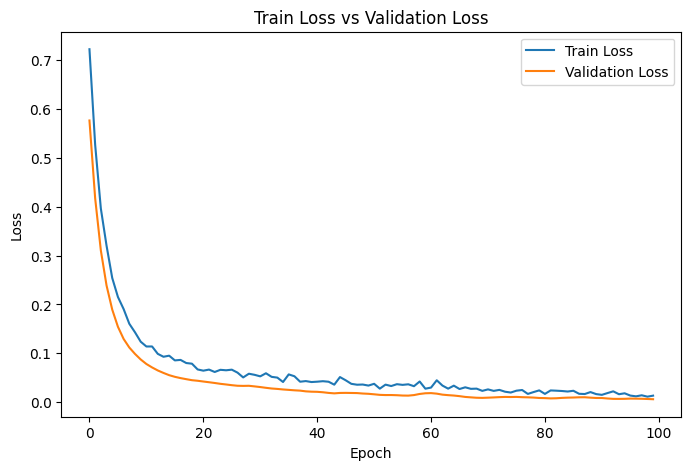

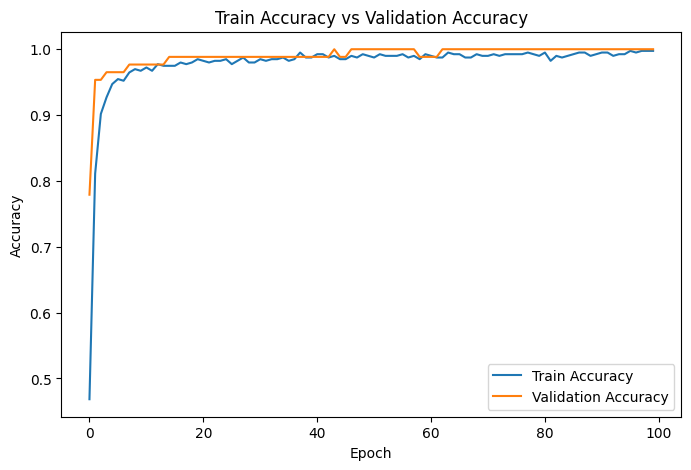

In [9]:
# ============================================================
# 9. 학습 곡선 시각화
# ============================================================

# history.history에는 epoch별 손실과 정확도 기록이 저장되어 있습니다.
history_dict = history.history

# 손실 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# 학습 손실을 선 그래프로 그립니다.
plt.plot(history_dict["loss"], label="Train Loss")

# 검증 손실을 선 그래프로 그립니다.
plt.plot(history_dict["val_loss"], label="Validation Loss")

# 그래프 제목을 설정합니다.
plt.title("Train Loss vs Validation Loss")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Loss")

# 범례를 표시합니다.
plt.legend()

# 그래프를 출력합니다.
plt.show()

# 정확도 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# 학습 정확도를 선 그래프로 그립니다.
plt.plot(history_dict["accuracy"], label="Train Accuracy")

# 검증 정확도를 선 그래프로 그립니다.
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")

# 그래프 제목을 설정합니다.
plt.title("Train Accuracy vs Validation Accuracy")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Accuracy")

# 범례를 표시합니다.
plt.legend()

# 그래프를 출력합니다.
plt.show()

In [10]:
# ============================================================
# 10. 테스트 데이터 최종 평가
# ============================================================

# evaluate는 테스트 데이터에 대한 손실과 정확도를 계산합니다.
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

# 테스트 손실과 정확도를 출력합니다.
print("테스트 손실:", round(test_loss, 4))
print("테스트 정확도:", round(test_acc, 4))

# predict는 각 샘플이 양성 클래스일 확률을 예측합니다.
test_probabilities = model.predict(X_test_scaled).ravel()

# 확률이 0.5 이상이면 1, 아니면 0으로 분류합니다.
test_predictions = (test_probabilities >= 0.5).astype(int)

# 정확도를 계산합니다.
accuracy = accuracy_score(y_test, test_predictions)

# 정밀도를 계산합니다.
precision = precision_score(y_test, test_predictions)

# 재현율을 계산합니다.
recall = recall_score(y_test, test_predictions)

# F1-score를 계산합니다.
f1 = f1_score(y_test, test_predictions)

# ROC-AUC를 계산합니다.
auc = roc_auc_score(y_test, test_probabilities)

# 결과를 출력합니다.
print("테스트 정확도 Accuracy:", round(accuracy, 4))
print("테스트 정밀도 Precision:", round(precision, 4))
print("테스트 재현율 Recall:", round(recall, 4))
print("테스트 F1-score:", round(f1, 4))
print("테스트 ROC-AUC:", round(auc, 4))

테스트 손실: 0.1326
테스트 정확도: 0.9419
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
테스트 정확도 Accuracy: 0.9419
테스트 정밀도 Precision: 0.9804
테스트 재현율 Recall: 0.9259
테스트 F1-score: 0.9524
테스트 ROC-AUC: 0.9919


In [11]:
# ============================================================
# 11. 혼동행렬 확인
# ============================================================

# 혼동행렬을 계산합니다.
cm = confusion_matrix(y_test, test_predictions)

# 혼동행렬을 출력합니다.
print("Confusion Matrix")
print(cm)

# 혼동행렬에서 TN, FP, FN, TP를 꺼냅니다.
tn, fp, fn, tp = cm.ravel()

# 각각의 의미를 출력합니다.
print("TN: 실제 0을 0으로 맞춘 개수 =", tn)
print("FP: 실제 0을 1로 잘못 예측한 개수 =", fp)
print("FN: 실제 1을 0으로 잘못 예측한 개수 =", fn)
print("TP: 실제 1을 1로 맞춘 개수 =", tp)

# 주요 분류 평가 지표를 표 형태로 출력합니다.
print("\nClassification Report")
print(classification_report(y_test, test_predictions, target_names=data.target_names))

Confusion Matrix
[[31  1]
 [ 4 50]]
TN: 실제 0을 0으로 맞춘 개수 = 31
FP: 실제 0을 1로 잘못 예측한 개수 = 1
FN: 실제 1을 0으로 잘못 예측한 개수 = 4
TP: 실제 1을 1로 맞춘 개수 = 50

Classification Report
              precision    recall  f1-score   support

   malignant       0.89      0.97      0.93        32
      benign       0.98      0.93      0.95        54

    accuracy                           0.94        86
   macro avg       0.93      0.95      0.94        86
weighted avg       0.95      0.94      0.94        86



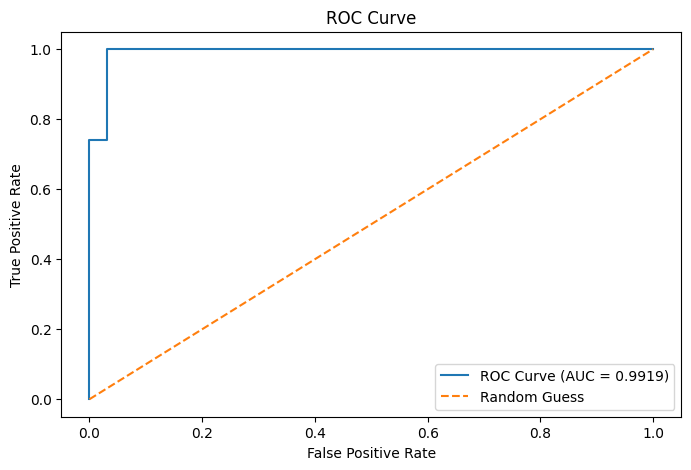

In [12]:
# ============================================================
# 12. ROC Curve 시각화
# ============================================================

# ROC Curve를 그리기 위해 FPR, TPR, Threshold를 계산합니다.
fpr, tpr, thresholds = roc_curve(y_test, test_probabilities)

# 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# ROC Curve를 그립니다.
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.4f})")

# 무작위 예측 기준선을 그립니다.
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

# 그래프 제목을 설정합니다.
plt.title("ROC Curve")

# x축 이름을 설정합니다.
plt.xlabel("False Positive Rate")

# y축 이름을 설정합니다.
plt.ylabel("True Positive Rate")

# 범례를 표시합니다.
plt.legend()

# 그래프를 출력합니다.
plt.show()

## 정리

이 노트북에서 확인한 핵심 흐름은 다음과 같습니다.

- 학습 데이터는 모델의 가중치를 학습하는 데 사용합니다.
- 검증 데이터는 학습 중 모델이 과적합되는지 확인하는 데 사용합니다.
- 테스트 데이터는 최종 모델 성능을 확인하는 데 사용합니다.
- Keras에서는 `validation_data`로 검증 데이터를 지정하면 epoch마다 검증 손실과 검증 정확도를 자동으로 확인할 수 있습니다.
- Accuracy뿐 아니라 Precision, Recall, F1-score, ROC-AUC를 함께 확인해야 모델의 성능을 더 정확하게 판단할 수 있습니다.